In [1]:
# PACKAGES
## data manipulation
import pandas as pd
import numpy as np

## confidence interval
import math

## hypothesis test
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## data viz
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# PATHS AND METHODS

## My min max scaler
def my_scaler(x_unscaled, x_min=None, x_max=None):
    if x_min == None:
        x_min=x_unscaled.min()
    if x_max == None:
        x_max=x_unscaled.max()
    x_scaled = (x_unscaled - x_min)/(x_max - x_min)
    return x_scaled

## confidence interval 95%
def my_ci_95(stats, r=2):
    
    ci95_hi = []
    ci95_lo = []
    alpha = []

    for i in stats.index:
        m, c, s = stats.loc[i]
        a = 1.96*s/math.sqrt(c)
        ci95_hi.append(m + a)
        ci95_lo.append(m - a)
        alpha.append(a)

    stats['ci95_lo'] = ci95_lo
    stats['ci95_hi'] = ci95_hi
    stats['alpha'] = alpha

    stats['mean'] = round(stats['mean'], r)
    stats['alpha'] = round(stats['alpha'], r)

    return(stats.reset_index())

In [3]:
# DEFINING EXPERIMENT PARAMETERS
## seed list
seed_list = [428956419, 1954324947, 1145661099, 1835732737, 794161987, 1329531353, 200496737, 633816299, 1410143363, 1282538739, 1029384756, 564738291, 918273645, 675849302, 123456789, 987654321, 246813579, 135792468, 1123581321, 314159265, 271828182, 161803398, 141421356, 173205080, 223606797, 707106781, 866025403, 577215664, 299792458, 602214076]
## scenarion list
scenario_list = ['sample']
## algorithms list
algo_list = ['tetris', 'thea', 'lix', 'edf', 'mcf', 'edfmcf']

In [4]:
# IMPORT DATASETS

# dataframes
total_seed_server = pd.DataFrame()
total_seed_user = pd.DataFrame()
total_seed_service = pd.DataFrame()
# object to count the quantity of experiments
n_exp = 0

# loop to get results
for algo_name in algo_list:

    for scenario in scenario_list:

        ## count experiment
        n_exp = n_exp + 1

        for seed_value in seed_list:

            # server
            ## getting results by seeds
            each_seed_server = pd.read_csv(f"results/{algo_name}_logsserver_{scenario}_{seed_value}.csv")
            each_seed_server['seed'] = seed_value
            each_seed_server['scenario'] = scenario
            each_seed_server['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_server = pd.concat([total_seed_server, each_seed_server])
            total_seed_server = total_seed_server.reset_index(drop=True)

            # user
            ## getting results by seeds
            each_seed_user = pd.read_csv(f"results/{algo_name}_logsuser_{scenario}_{seed_value}.csv")
            each_seed_user['seed'] = seed_value
            each_seed_user['scenario'] = scenario
            each_seed_user['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_user = pd.concat([total_seed_user, each_seed_user])
            total_seed_user = total_seed_user.reset_index(drop=True)

            # service
            ## getting results by seeds
            each_seed_service = pd.read_csv(f"results/{algo_name}_logsservice_{scenario}_{seed_value}.csv")
            each_seed_service['seed'] = seed_value
            each_seed_service['scenario'] = scenario
            each_seed_service['algorithm'] = algo_name
            ## save results of all seeds for each experiment
            total_seed_service = pd.concat([total_seed_service, each_seed_service])
            total_seed_service = total_seed_service.reset_index(drop=True)

In [5]:
# FEATURE ENGINEERING

## create new obj to do feature engineering
dt_power = total_seed_server.loc[(total_seed_server['Available'])].reset_index(drop=True).copy()
dt_server = total_seed_server.loc[(total_seed_server['Available']) & (total_seed_server['CPU Demand'] > 0)].reset_index(drop=True).copy()
dt_user = total_seed_user.copy()
dt_service = total_seed_service.copy()

## user dataset
# compute sla violation variable
dt_user['sla_violations'] = 0
dt_user.loc[dt_user['Delay sla deadlines'] < 0, 'sla_violations'] = 1
dt_user['cumulative_sla_violations'] = dt_user.groupby(['algorithm', 'scenario', 'seed'])['sla_violations'].cumsum()

## server dataset
# compute server access
dt_server['server_access'] = 0
dt_server.loc[dt_server['CPU Demand'] > 0, 'server_access'] = 1
dt_server['cumulative_server_access'] = dt_server.groupby(['Instance ID', 'algorithm', 'scenario', 'seed'])['server_access'].cumsum()
dt_total_server_access = dt_server.groupby(['algorithm', 'scenario', 'seed'])['server_access'].sum().reset_index().rename(columns={'server_access':'total_server_access'})
dt_server = dt_server.merge(dt_total_server_access, how='left', on=['algorithm', 'scenario', 'seed'])
dt_total_server_access_avg = dt_server.loc[dt_server['Time Step'] == 60].groupby(by=['algorithm', 'Object', 'scenario'])['total_server_access'].agg(['mean', 'count']).reset_index()
dt_total_server_access_avg['product'] = dt_total_server_access_avg['mean']*dt_total_server_access_avg['count']
dt_total_server_access_avg = dt_total_server_access_avg.merge(dt_total_server_access_avg.groupby(by=['algorithm', 'scenario'])['product'].agg(['sum']).reset_index(), how='left', on=['algorithm', 'scenario'])
dt_total_server_access_avg['weight'] = dt_total_server_access_avg['product']/dt_total_server_access_avg['sum']
dt_total_server_access_avg['n_server_access'] = dt_total_server_access_avg['mean']*dt_total_server_access_avg['weight']
dt_total_server_access_avg = dt_total_server_access_avg.groupby(by=['algorithm', 'scenario'])['n_server_access'].agg(['sum']).reset_index().rename(columns={'sum':'n_server_access'})
dt_server_access_avg = dt_server.loc[dt_server['Time Step'] == 60].groupby(by=['algorithm', 'Object', 'scenario'])['cumulative_server_access'].agg(['mean', 'count']).reset_index()
dt_server_access_avg['product'] = dt_server_access_avg['mean']*dt_server_access_avg['count']
dt_server_access_avg = dt_server_access_avg.merge(dt_server_access_avg.groupby(by=['algorithm', 'scenario'])['product'].agg(['sum']).reset_index(), how='left', on=['algorithm', 'scenario'])
dt_server_access_avg['weight'] = dt_server_access_avg['product']/dt_server_access_avg['sum']
dt_server_access_avg = dt_server_access_avg.merge(dt_total_server_access_avg, how='left', on=['algorithm', 'scenario'])
dt_server_access_avg['server_access_by_server'] = dt_server_access_avg['n_server_access']*dt_server_access_avg['weight']

# compute free resources
dt_server['CPU Free'] = dt_server['CPU'] - dt_server['CPU Demand']
dt_server['RAM Free'] = dt_server['RAM'] - dt_server['RAM Demand']
# compute usage metrics
dt_server['CPU Usage'] = (dt_server['CPU Demand'] * 100) / dt_server['CPU']
dt_server['RAM Usage'] = (dt_server['RAM Demand'] * 100) / dt_server['RAM']
dt_server['Servers Usage'] = (dt_server['CPU Usage'] + dt_server['RAM Usage']) / 2

# create new obj withou cloud server
dt_server_edge = dt_server.loc[(dt_server['Instance ID'] != 7)].reset_index(drop=True)

# normalization
## CPU
dt_server_edge.loc[:, 'CPU Free_norm'] = my_scaler(x_unscaled=dt_server_edge.loc[:, 'CPU Free'])
## RAM
dt_server_edge.loc[:, 'RAM Free_norm'] = my_scaler(x_unscaled=dt_server_edge.loc[:, 'RAM Free'])
# compute Resource Imbalance Index (RII)
dt_server_edge['RII'] = dt_server_edge[['CPU Free_norm', 'RAM Free_norm']].std(axis=1)

In [6]:
# RESULTS TO USE ON OVERLEAF PLOTS

## SLA Violations
stats_sla = dt_user.loc[dt_user['Time Step'] == 60].groupby(by=['algorithm', 'scenario'])['cumulative_sla_violations'].agg(['mean', 'count', 'std'])
stats_sla = my_ci_95(stats_sla)
print(">>>>>>>>>>>>>>>>>>>> cumulative_sla_violations <<<<<<<<<<<<<<<<<<<<\n", stats_sla[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Delay
stats_delay = dt_user.groupby(by=['algorithm', 'scenario'])['Delays'].agg(['mean', 'count', 'std'])
stats_delay = my_ci_95(stats_delay)
print(">>>>>>>>>>>>>>>>>>>> Delays <<<<<<<<<<<<<<<<<<<<\n", stats_delay[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Power Consumption
stats_power = dt_power.groupby(by=['algorithm', 'scenario'])['Power Consumption'].agg(['mean', 'count', 'std'])
stats_power = my_ci_95(stats_power)
print(">>>>>>>>>>>>>>>>>>>> Power <<<<<<<<<<<<<<<<<<<<\n", stats_power[['algorithm', 'scenario', 'mean', 'alpha']], '\n')

## Percent Server Access
stats_access = dt_server_access_avg.groupby(by=['algorithm', 'Object', 'scenario'])['weight'].agg(['mean', 'count', 'std'])
stats_access = my_ci_95(stats_access,  r=2)
stats_access['mean_percent'] = stats_access['mean']*100
print(">>>>>>>>>>>>>>>>>>>> Server Access <<<<<<<<<<<<<<<<<<<<\n", stats_access[['algorithm', 'Object', 'scenario', 'mean_percent']], '\n')

>>>>>>>>>>>>>>>>>>>> cumulative_sla_violations <<<<<<<<<<<<<<<<<<<<
   algorithm scenario   mean  alpha
0       edf   sample  30.47   0.83
1    edfmcf   sample  59.50   0.13
2       lix   sample  58.50   0.13
3       mcf   sample  59.72   0.11
4    tetris   sample   0.00   0.00
5      thea   sample   0.00   0.00 

>>>>>>>>>>>>>>>>>>>> Delays <<<<<<<<<<<<<<<<<<<<
   algorithm scenario    mean  alpha
0       edf   sample   79.29   3.03
1    edfmcf   sample  134.24   3.38
2       lix   sample  120.00   3.62
3       mcf   sample  133.17   3.42
4    tetris   sample   22.46   0.27
5      thea   sample   25.50   0.22 

>>>>>>>>>>>>>>>>>>>> Power <<<<<<<<<<<<<<<<<<<<
   algorithm scenario    mean  alpha
0       edf   sample  116.68   1.24
1    edfmcf   sample  109.44   1.26
2       lix   sample  110.51   1.24
3       mcf   sample  109.48   1.25
4    tetris   sample  123.67   1.36
5      thea   sample  133.38   1.08 

>>>>>>>>>>>>>>>>>>>> Server Access <<<<<<<<<<<<<<<<<<<<
    algorithm        

ANOVA: null hypothesis (H₀): All group means are equal
F-statistic: 26637.69
p-value: 0.000000000
Tukey HSD Post-hoc Test: which ones differ significantly?
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   edf edfmcf  29.0333    0.0  28.3109  29.7558   True
   edf    lix  28.0333    0.0  27.3109  28.7558   True
   edf    mcf    29.25    0.0  28.5275  29.9725   True
   edf tetris -30.4667    0.0 -31.1891 -29.7442   True
   edf   thea -30.4667    0.0 -31.1891 -29.7442   True
edfmcf    lix     -1.0 0.0012  -1.7225  -0.2775   True
edfmcf    mcf   0.2167 0.9558  -0.5058   0.9391  False
edfmcf tetris    -59.5    0.0 -60.2225 -58.7775   True
edfmcf   thea    -59.5    0.0 -60.2225 -58.7775   True
   lix    mcf   1.2167    0.0   0.4942   1.9391   True
   lix tetris    -58.5    0.0 -59.2225 -57.7775   True
   lix   thea    -58.5    0.0 -59.2225 -57.7775   True
   mcf tetris -59.7

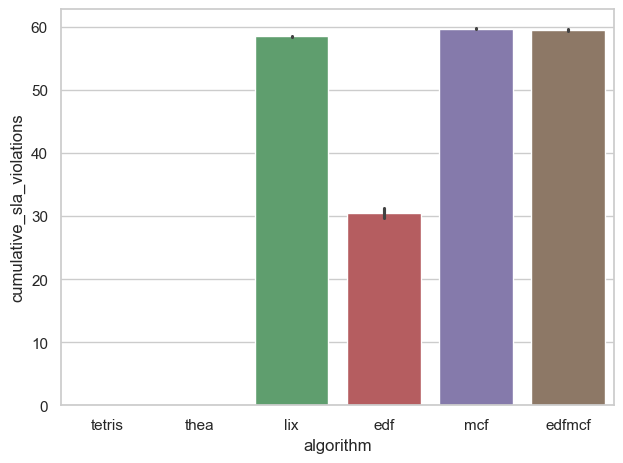

In [7]:
# SLA VIOLATION DATA-VIZ

# Perform one-way ANOVA
dt_user_sla = dt_user.loc[dt_user['Time Step'] == 60].reset_index().copy()
anova_result = stats.f_oneway(*[group["cumulative_sla_violations"].values for name, group in dt_user_sla.groupby("algorithm")])
# Print ANOVA results
# Null hypothesis (H₀): All group means are equal.
# Alternative hypothesis (H₁): At least one group mean is different.
print("ANOVA: null hypothesis (H₀): All group means are equal")
print(f"F-statistic: {anova_result.statistic:.2f}")
print(f"p-value: {anova_result.pvalue:.9f}")
# Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(endog=dt_user_sla["cumulative_sla_violations"], groups=dt_user_sla["algorithm"], alpha=0.05)
# Print Tukey HSD results
# Compare all possible pairs of group means to find which ones differ significantly.
print("Tukey HSD Post-hoc Test: which ones differ significantly?")
print(tukey_result)

# Set the seaborn style
sns.set(style="whitegrid")
# Create the plot
#plt.figure(figsize=(10, 5))
sns.barplot(data=dt_user.loc[dt_user['Time Step'] == 60].reset_index(), x='algorithm', y='cumulative_sla_violations', hue='algorithm', estimator=np.mean, errorbar=('ci', 95))
# Ensure all time steps from 0 to 10 are shown on the x-axis
#plt.xticks(ticks=range(0, 11))
plt.tight_layout()
plt.show()

ANOVA: null hypothesis (H₀): All group means are equal
F-statistic: 1365.57
p-value: 0.000000000
Tukey HSD Post-hoc Test: which ones differ significantly?
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
   edf edfmcf   54.9435    0.0   49.2855   60.6015   True
   edf    lix   40.7062    0.0   35.0483   46.3642   True
   edf    mcf   53.8786    0.0   48.2206   59.5366   True
   edf tetris  -56.8361    0.0  -62.4941  -51.1781   True
   edf   thea   -53.798    0.0   -59.444  -48.1519   True
edfmcf    lix  -14.2373    0.0  -19.9009   -8.5737   True
edfmcf    mcf    -1.065 0.9947   -6.7285    4.5986  False
edfmcf tetris -111.7797    0.0 -117.4432 -106.1161   True
edfmcf   thea -108.7415    0.0 -114.3932 -103.0898   True
   lix    mcf   13.1723    0.0    7.5087   18.8359   True
   lix tetris  -97.5424    0.0 -103.2059  -91.8788   True
   lix   thea  -94.5042    0.0 -1

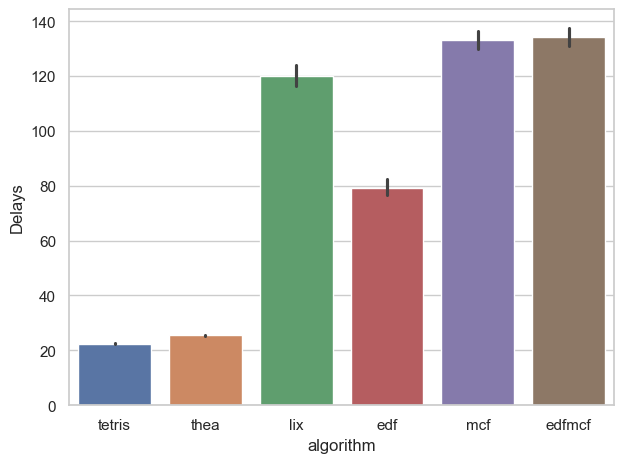

In [8]:
# LATENCY DATA-VIZ

# Perform one-way ANOVA
dt_user_delay = dt_user.dropna(subset=['Delays']).copy()
anova_result = stats.f_oneway(*[group["Delays"].values for name, group in dt_user_delay.groupby("algorithm")])
# Print ANOVA results
# Null hypothesis (H₀): All group means are equal.
# Alternative hypothesis (H₁): At least one group mean is different.
print("ANOVA: null hypothesis (H₀): All group means are equal")
print(f"F-statistic: {anova_result.statistic:.2f}")
print(f"p-value: {anova_result.pvalue:.9f}")
# Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(endog=dt_user_delay["Delays"], groups=dt_user_delay["algorithm"], alpha=0.05)
# Print Tukey HSD results
# Compare all possible pairs of group means to find which ones differ significantly.
print("Tukey HSD Post-hoc Test: which ones differ significantly?")
print(tukey_result)

# Set the seaborn style
sns.set(style="whitegrid")
# Create the plot
#plt.figure(figsize=(10, 5))
sns.barplot(data=dt_user, x='algorithm', y='Delays', hue='algorithm', estimator=np.mean, errorbar=('ci', 95))
# Ensure all time steps from 0 to 10 are shown on the x-axis
#plt.xticks(ticks=range(0, 11))
plt.tight_layout()
plt.show()

ANOVA: null hypothesis (H₀): All group means are equal
F-statistic: 233.25
p-value: 0.000000000
Tukey HSD Post-hoc Test: which ones differ significantly?
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   edf edfmcf  -7.2361    0.0 -9.7904 -4.6819   True
   edf    lix  -6.1641    0.0 -8.7184 -3.6098   True
   edf    mcf  -7.1956    0.0 -9.7499 -4.6413   True
   edf tetris   6.9985    0.0  4.4442  9.5528   True
   edf   thea  16.7016    0.0 14.1474 19.2559   True
edfmcf    lix   1.0721 0.8389 -1.4822  3.6263  False
edfmcf    mcf   0.0405    1.0 -2.5138  2.5948  False
edfmcf tetris  14.2346    0.0 11.6804 16.7889   True
edfmcf   thea  23.9378    0.0 21.3835 26.4921   True
   lix    mcf  -1.0315 0.8599 -3.5858  1.5227  False
   lix tetris  13.1626    0.0 10.6083 15.7169   True
   lix   thea  22.8657    0.0 20.3114   25.42   True
   mcf tetris  14.1941    0.0 11.6398 16.7484   Tru

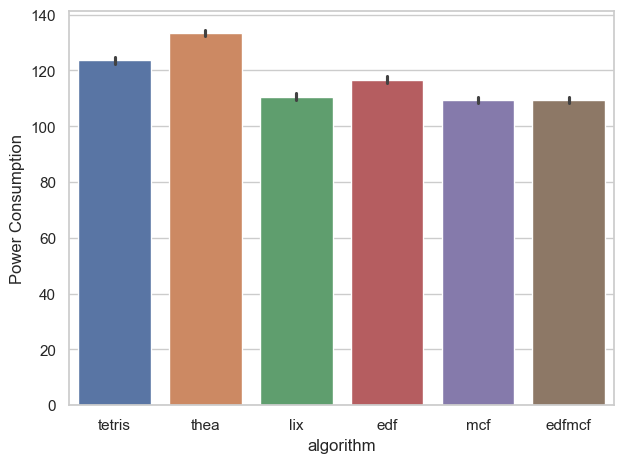

In [9]:
# POWER DATA-VIZ

# Perform one-way ANOVA
dt_server_power = dt_power.copy()
anova_result = stats.f_oneway(*[group["Power Consumption"].values for name, group in dt_server_power.groupby("algorithm")])
# Print ANOVA results
# Null hypothesis (H₀): All group means are equal.
# Alternative hypothesis (H₁): At least one group mean is different.
print("ANOVA: null hypothesis (H₀): All group means are equal")
print(f"F-statistic: {anova_result.statistic:.2f}")
print(f"p-value: {anova_result.pvalue:.9f}")
# Perform Tukey's HSD test
tukey_result = pairwise_tukeyhsd(endog=dt_server_power["Power Consumption"], groups=dt_server_power["algorithm"], alpha=0.05)
# Print Tukey HSD results
# Compare all possible pairs of group means to find which ones differ significantly.
print("Tukey HSD Post-hoc Test: which ones differ significantly?")
print(tukey_result)

# Set the seaborn style
sns.set(style="whitegrid")
# Create the plot
#plt.figure(figsize=(10, 5))
sns.barplot(data=dt_power, x='algorithm', y='Power Consumption', hue='algorithm', estimator=np.mean, errorbar=('ci', 95))
# Ensure all time steps from 0 to 10 are shown on the x-axis
#plt.xticks(ticks=range(0, 11))
plt.tight_layout()
plt.show()

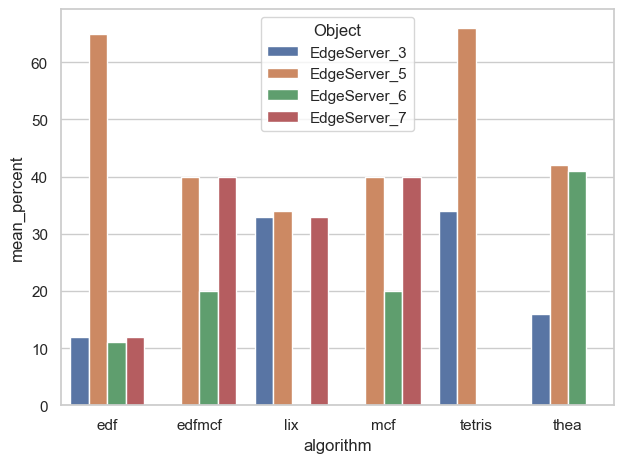

In [10]:
# SERVER ACCESS DATA-VIZ

# Set the seaborn style
sns.set(style="whitegrid")
# Create the plot
#plt.figure(figsize=(10, 5))
sns.barplot(data=stats_access, x='algorithm', y='mean_percent', hue='Object')
# Ensure all time steps from 0 to 10 are shown on the x-axis
#plt.xticks(ticks=range(0, 11))
plt.tight_layout()
plt.show()